# Linear Regression with Gradient Descent

In [22]:
# y = 2x + 5 + noise

In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

In [24]:
# Generate random synthetic data
# Our data will have one feature(x) and one target variable(y)
# y = 2x + 5 + noise
np.random.seed(0) # for reproducibility


X = 2 * np.random.rand(100, 1) # 100 data points, 1 input feature
y = 5 + 2 * X + np.random.randn(100, 1) # linear relation with some noise


print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"First 5 entries of X:\n{X[:5]}")
print(f"First 5 entries of y:\n{y[:5]}")

X shape: (100, 1), y shape: (100, 1)
First 5 entries of X:
[[1.09762701]
 [1.43037873]
 [1.20552675]
 [1.08976637]
 [0.8473096 ]]
First 5 entries of y:
[[6.03010417]
 [8.76158395]
 [7.87671594]
 [5.64328905]
 [8.18287139]]


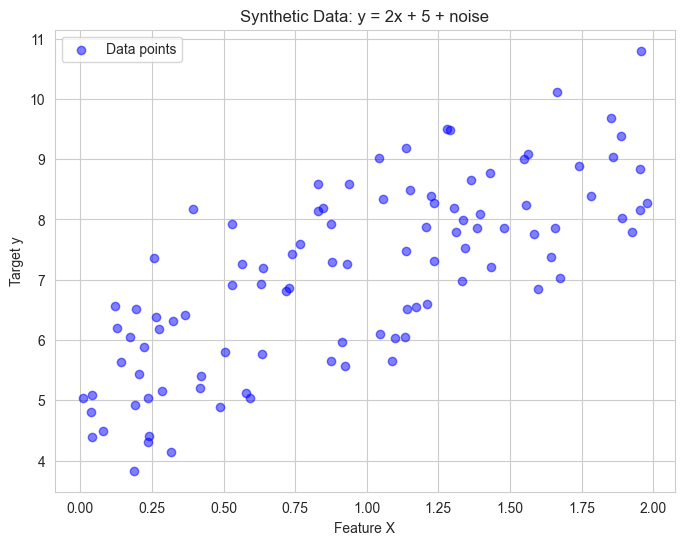

In [25]:
# Plotting the data
plt.figure(figsize=(8, 6))
plt.scatter(X, y, color='blue', alpha=0.5, label='Data points')
plt.xlabel('Feature X')
plt.ylabel('Target y')
plt.title('Synthetic Data: y = 2x + 5 + noise')
plt.legend()
plt.show()

In [26]:
# Initialize model parameters (Weights and Bias)
# For y = w*x + b, we need to initialize w and b

w = np.random.randn(1,1) # weight
b = np.random.randn(1, 1) # bias


print(f"Initial weight (w): {w}")
print(f"Initial bias (b): {b}")

Initial weight (w): [[-0.35399391]]
Initial bias (b): [[-1.37495129]]


In [27]:
# Define Hyperparameters
learning_rate = 0.01
n_epochs = 1000 # number of iterations for Gradient Descent

In [28]:
# Store loss and parameters history for visualization
loss_history = []
w_history = []
b_history = []

In [34]:
# Training Loop (Gradient Descent)
for epoch in range(n_epochs):
    # In Linear Algebra, Calculate predictions as Y_pred = w*X + b
    y_pred = X @ w + b  # Using @ for matrix multiplication, '+' uses broadcasting for bias

    # Calculate Mean Squared Error Loss
    errors = y_pred - y
    mse_loss = np.mean(errors ** 2)

    loss_history.append(mse_loss)
    w_history.append(w.flatten()[0])
    b_history.append(b.flatten()[0])

    # Calculus: Calculate Gradients (Partial Derivatives of Loss w.r.t w and b)
    # dw = 2/N * sum((y_pred - y) * X)
    # db = 2/N * sum(y_pred - y)
    dw = (2 / len(X)) * (X.T @ errors) # X.T @ errors is equivalent to sum((y_pred - y) * X)
    db = (2 / len(X)) * np.sum(errors)

    # Optimization: Update parameters using Gradient Descent
    w = w - learning_rate * dw
    b = b - learning_rate * db

    if epoch % 100 == 0:
        print(f"Epoch {epoch}: Loss = {mse_loss}, w = {w.flatten()[0]}, b = {b.flatten()[0]}")

    

print("Training Complete.")
print(f"Final trained weight (w): {w.flatten()[0]}")
print(f"Final trained bias (b): {b.flatten()[0]}")
print(f"Final Loss: {mse_loss}")

Epoch 0: Loss = 0.9924432920418375, w = 1.972020922357158, b = 5.2181464649765275
Epoch 100: Loss = 0.9924410852738288, w = 1.9710415723118415, b = 5.219250169749346
Epoch 200: Loss = 0.9924399272872936, w = 1.9703321393501818, b = 5.2200496842329756
Epoch 300: Loss = 0.9924393196417189, w = 1.9698182320608573, b = 5.220628845821546
Epoch 400: Loss = 0.9924390007838275, w = 1.9694459619292264, b = 5.221048385620438
Epoch 500: Loss = 0.9924388334653131, w = 1.9691762925670973, b = 5.221352296733208
Epoch 600: Loss = 0.9924387456660584, w = 1.9689809463421646, b = 5.221572447395212
Epoch 700: Loss = 0.9924386995939953, w = 1.9688394391746626, b = 5.221731922688961
Epoch 800: Loss = 0.992438675417993, w = 1.9687369325689648, b = 5.221847445254661
Epoch 900: Loss = 0.9924386627318, w = 1.9686626776432425, b = 5.22193112883268
Training Complete.
Final trained weight (w): 1.9686093445663713
Final trained bias (b): 5.221991233972586
Final Loss: 0.9924386561223564


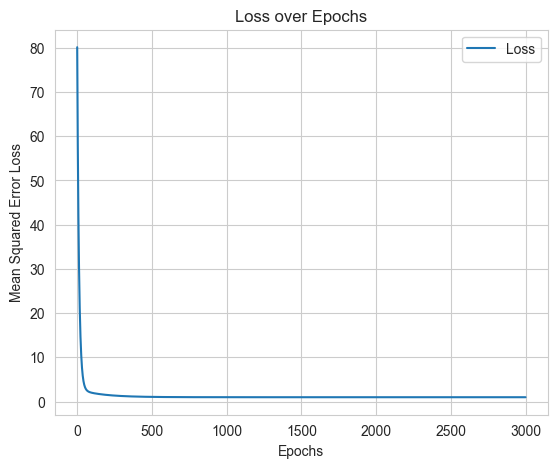

In [35]:
# Visualization of Training Progress
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(loss_history, label='Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error Loss')
plt.legend()
plt.show()

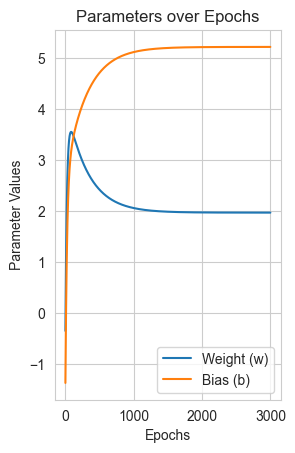

In [36]:
plt.subplot(1, 2, 2)
plt.plot(w_history, label='Weight (w)')
plt.plot(b_history, label='Bias (b)')
plt.title('Parameters over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Parameter Values')
plt.legend()

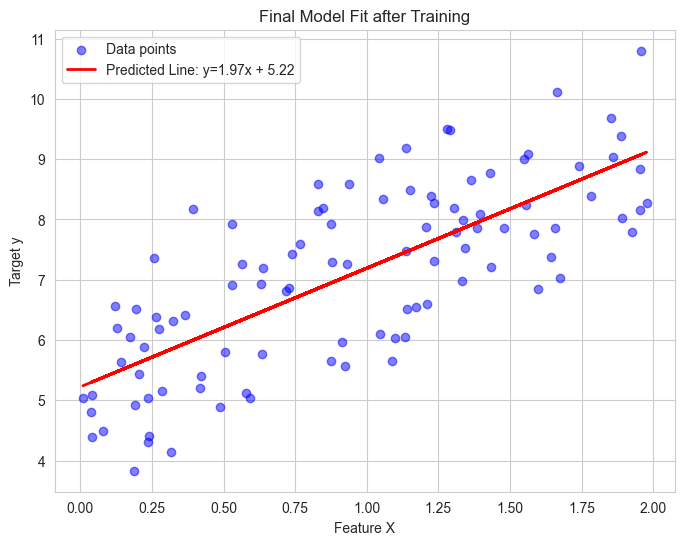

Mean of Residuals: 2.5727119097611608e-05
Variance of Residuals: 0.9924386554129215


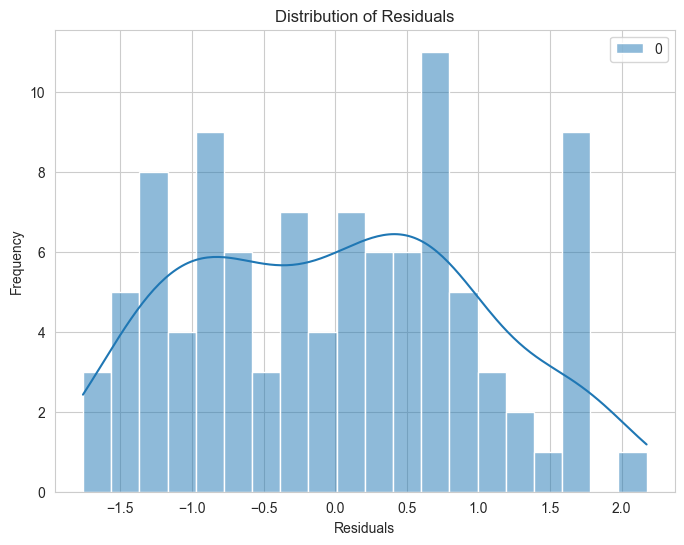

In [40]:
# Evaluate model performance and visualize Final Fit
final_y_pred = X @ w + b

plt.figure(figsize=(8, 6))
plt.scatter(X, y, color='blue', alpha=0.5, label='Data points')
plt.plot(X, final_y_pred, color='red', linewidth=2, label=f"Predicted Line: y={w.flatten()[0]:.2f}x + {b.flatten()[0]:.2f}")
plt.xlabel('Feature X')
plt.ylabel('Target y')
plt.title('Final Model Fit after Training')
plt.legend()
plt.show()


residuals = y - final_y_pred
print(f"Mean of Residuals: {np.mean(residuals)}")
print(f"Variance of Residuals: {np.var(residuals)}")

plt.figure(figsize=(8, 6))
sns.histplot(residuals, bins=20, kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()